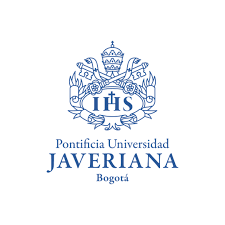
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: J. Corredor (Aqui Nombre y Apellido de Autor (Uds.)

Fecha de Inicio: 

Fecha actual: 

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1.- Importación de bibliotecas**

# Levantamiento de variables de entorno pip
import os

import sys

sys.path.append('/usr/lib/python3/dist-packages/')

import numpy as np

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from pylab import *

import findspark

findspark.init()

import pyspark.sql.functions as F

from pyspark import SparkConf, SparkContext

from pyspark.sql import SQLContext

from pyspark.sql import SparkSession

from pyspark.sql.types import *

### Levantamiento de sesión SPARK
configura = SparkConf()

configura.setAppName("Calidad_Agua_Corredor")

sparkS = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)

sparkContextoS = sparkS.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos04")

sparkCorredor

##**2.- Carga de Datos desde el HADOOP HDFS**

!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

df00 = sparkS.read.format("csv").option("header", "true").load("hdfs://10.195.34.34:9000/csv/waterquality.csv")

df00.show(5)

## **3.- Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

In [ ]:
##Conocimiento de las columnas
df00.columns

- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

**Se presenta las estadísticas de los datos a continuación:**

for valor in df00.columns:
  
  df00.describe([valor]).show()

## **Visualización de los DATOS NULOS**

#Cantidad de Valores Nulos o Imposibles

df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()



* Se observa que no hay datos nulos o imposibles
* Se procede a Graficar cada una de las dimensiones
* #Se crea una vista para ser usada en las visualizaciones
* df00.createOrReplaceTempView("df00_sql")
* df01 = sparkS.sql('''Select * from df00_sql where TEMP is not null and
  
             DO is not null and
  
             pH is not null and
  
             CONDUCTIVITY is not null and
  
             BOD is not null and
  
             NITRATE_N_NITRITE_N is not null and
  
             FECAL_COLIFORM is not null''')

* #Se verifica la Cantidad de Valores Nulos o Imposibles
* df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

### **Tratamiento de datos**

* df00.dtypes
* ##Se procede a cambiar los tipos de datos
* df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))
* df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))
* df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))
* df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))
* df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
* df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))
* df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))
* df00.dtypes


* ##Se elimina la columna TOTAL_COLIFORM
* df01 = df00.drop('TOTAL_COLIFORM')
* df01.columns

## **Creación de Tablas para Visualizar los Datos**

- Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos

- df01.createOrReplaceTempView("df01_sql")

- ###Se crea una consulta por cada parámetro DO
- do_parametro = sparkS.sql("Select DO from df01_sql")
- ##Se hace una consulta para crear el vector de la tabla por cada parámetro
- do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()

- pH
- CONDUCTIVITY
- BOD
- NITRATE_N_NITRITE_N
- FECAL_COLIFORM 

* ###Grafica Los parámetros para conocer sus características: DO y PH

* tam = len(do_parametro)
* fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
* ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')
* ax1.plot(range(0,tam), ph_parametro, label='pH')
* fig.suptitle('Parámetro DO y pH de la calidad del Agua')
* legend=ax1.legend()
* plt.grid()
* plt.show()

* ###Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos

* tam = len(do_parametro)
* fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
* ax1.plot(range(0,tam), BOD_parametro, label='Oxigeno Disuelto')
* ax1.plot(range(0,tam), NN_parametro, label='NITRATE_N_NITRITE_N')
* fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')
* legend=ax1.legend()
* plt.grid()
* plt.show()

* ###Grafica Los parámetros para conocer sus características: FC y Conductividad

* tam = len(do_parametro)
* fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
* ax1.plot(range(0,tam), COND_parametro, label='Conductividad')
* ax1.plot(range(0,tam), FC_parametro, label='FC_parametro')
* fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
* legend=ax1.legend()
* plt.xlabel("Hola que tal estas")
* plt.grid()
* plt.show()

* #Función definida por el usuario para definir el rango de calidad de agua según el pH
* #Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)

* df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).

       when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).

       when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).

       when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según DO
* df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
  *                    when((df01.DO>=5.1) & (df01.DO<6.0), 80).
  *                    when((df01.DO>=4.1) & (df01.DO<5.0), 60).
  *                    when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según COND
* df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).
  *          when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
  *          when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
  *          when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según BOD
* df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).
  *                     when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
  *                     when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
  *                     when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según NITRATE_N_NITRITE_N
    * ### 100: Agua Dulce
    * ### 80: Agua Moderada
    * ### 60: Agua Dura
    * ### 40: Agua muy Dura
* df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
  *                     when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
  *                     when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
  *                     when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según el Material Fecal
  *  ### 100: Agua Dulce
  *  ### 80: Agua Moderada
  *  ### 60: Agua Dura
  *  ### 40: Agua muy Dura

* df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
   *                    when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
   *                    when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
   *                    when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

##**El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua**

* #A continuación se hace una inspección en general del df02
     * df02.show(10)
* ##Nombre de Columnas
     * df02.columns

## **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**

* ###Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad
    * df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
    * df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
    * df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
    * df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
    * df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
    * df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

* df03.show(10)

* df03.columns

### **Calculo del Índice de Calidad del Agua**

   - Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

   - df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
   - df04.show(10)

**Intervalos de Índices para WQI**

- Excelente: agua dulce ***WQI = [0.0 , 25.0]***
- Buena: agua moderada ***WQI = (25.0 , 50.0]***
- Baja: agua dura ***WQI = (50.0 , 75.0]***
- Muy_Baja: agua muy dura ***WQI = (75.0 , 100.0]***
- Inadecuada: agua residual ***WQI > 100***

* df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')
   * .when((df04.WQI>=25) & (df04.WQI<50),'Buena')
   * .when((df04.WQI>=50) & (df04.WQI<75),'Baja')
   * .when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
   * .otherwise('Inadecuada')
                      )
* df05.show(10)

### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua

- #Impresión de nombre de regiones sobre el mapa

* colEstado = 'STATE'
* valNomnbres = df05.select(colEstado).distinct().collect()
* valNomnbres = [v[colEstado] for v in valNomnbres]

* print(valNomnbres)


#### **Se cargan los datos de los mapas disponibles**

- Los ficheros comprimidos "dbf", "prj", "shp", "shx" deben estar juntos en una carpeta

- import geopandas as gpd

- rutaMapas = "/home/sistemas/Documents/ProcDatos/TallerWaterCorredor/Indian_States.shp"
- ## Se carga un objeto dataframe de los datos comprimidos de los mapas
- gpd01 = gpd.read_file(rutaMapas)

- ## Se visualiza el tipo de dataframe que da geopandas y las columnas 

print(type(gpd01))

gpd01.columns


- #Se visualizan los nombres de la columna de los estados "st_nm"
- gpd01["st_nm"].unique()

- ### Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan 
- ### con los nombres de los estados del dataframe de datos inicial

- gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
  -                     'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
  -                    'Daman & Diu': 'Daman Diu', 
  -                     'Jammu & Kashmir': 'Jammu Kashmir',
  -                     'NCT of Delhi' : 'Delhi'
                      })
- gpd02["st_nm"].unique()

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan es formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

In [ ]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

In [ ]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### **Se pinta el mapa inicial**

In [ ]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

#### *-Se requiere superponer las etiquetas de los estados de la India en el MAPA*

In [ ]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

In [ ]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

### **Histograma de WQI por Estado**

In [ ]:
df06.createOrReplaceTempView("df06_sql")
#Se seleccionan los nombres de los estados
Estados = sparkS.sql("Select STATE from df06_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

## Seleccionamos los valores de WQI
wqi = sparkS.sql("Select WQI from df06_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

##Se grafica el histograma
plt.barh(Estados,wqi)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI<25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid()
plt.show()

### **Creación de Modelo: Calidad de Agua en la India**

    - Se requiere predecir el parámetro WQI
    - Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
    - Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
    - Se importa Keras Sequential Layers Dense
    - Se inicializa el modelo, y se añaden las capas
    - Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
    - Se realiza el experimento sobre los datos de entrenamiento
    - Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

In [ ]:
df06.columns

In [ ]:
#- Se requiere predecir el parámetro WQI
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"

dfcalidad = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
dfPredecir = df06.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

In [ ]:
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
#- Se importa Scikit-Learn, para separar los datos (Entrenamiento: 80% y Prueba: 20%)

from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1)

In [ ]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

In [ ]:
## Se importa la instancia TensorFlow
import keras
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
#Se ajustan las variables: El ajuste es de forma estandar. Se requiere un estudio profundo sobre el
# ajuste de los parámetros, para que sea el modelo mucho más eficiente. El estudio a continuación
# es un a guia para abordar modelos de Tensores en Predicción de calidad de agua, como guía metodológica
# académica.

epocas = 200
lote = 81
#Se inicializa el modelo con las capas
modelo01 = Sequential()
modelo01.add(Dense(350,input_dim=6,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(1,activation='linear'))

In [ ]:
#Para optimizar el modelo se usa el optimizador ADAM
#La compilación se ajusta a la pérdida del error cuadrático
keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

In [ ]:
modelo01.summary()

In [ ]:
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote)

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(ejecutarK.history['loss'])
plt.title("Aqui el Titulo")
plt.xlabel("etiqueta X")
plt.show()

In [ ]:
### Se requiere predecir sobre los datos del entrenamiento
predModelo01_Train = modelo01.predict(dataTrain)

In [ ]:
### Se pinta la predicción
plt.plot(dataTrain, 'bo', predModelo01_Train, 'g+')
plt.show()